# 01 — Data Acquisition (QBUS3850 Option A)

**Persona:** Qantas Group — joint fuel + AUDUSD hedger.
**Primary source:** Yahoo Finance via `yfinance`.
**Secondary source:** EIA v2 API (downloaded the xls files).
**Date range:** 2016-01-01 → 2026-05-15.
**Outputs:**
- `data/raw/*.csv` — one per Yahoo ticker
- `data/processed/prices.parquet` + `.csv` — price-like series (futures, ETFs, FX, auxiliary equities)
- `data/processed/returns.parquet` — log returns
- `data/processed/exogenous_features.parquet` — RF, TNX, DXY, OilVol, VIX
- `data/processed/summary.csv` — per-ticker date ranges and missingness
- `figures/01_acquisition/*.png` — 3 overview figures
- `data/quality/tracking_gap_report.csv` — ETF vs futures tracking diagnostic

**Hand-off contract for M2/M3/M4:** read from the three parquet files above. They are the canonical inputs to EDA, modelling, and backtesting. Never read from `data/raw/` downstream.


In [ ]:
import subprocess
import sys
from datetime import datetime, timedelta
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from curl_cffi import requests as curl_requests

# Browser-impersonating session — bypasses Yahoo's yfinance block.
# Shared across all yf.download / yf.Ticker calls below.
YF_SESSION = curl_requests.Session(impersonate="chrome")


def _find_project_root() -> Path:
    """Walk up from cwd looking for a directory containing both
    requirements.txt and notebooks/. Works whether the notebook is run
    from the project root, from notebooks/, or anywhere within the tree."""
    cwd = Path.cwd().resolve()
    for parent in [cwd, *cwd.parents]:
        if (parent / "requirements.txt").exists() and (parent / "notebooks").is_dir():
            return parent
    raise RuntimeError(
        f"Could not locate project root from {cwd}. "
        "Expected a parent directory with both requirements.txt and notebooks/."
    )


PROJECT_ROOT  = _find_project_root()
RAW_DIR       = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
QUALITY_DIR   = PROJECT_ROOT / "data" / "quality"
FIGURES_DIR   = PROJECT_ROOT / "figures" / "01_acquisition"
LOG_PATH      = RAW_DIR / "_acquisition_log.csv"

for d in (RAW_DIR, PROCESSED_DIR, QUALITY_DIR, FIGURES_DIR):
    d.mkdir(parents=True, exist_ok=True)

START = "2016-01-01"
END   = "2026-05-15"

TICKERS = {
    # ---- Forecast targets: front-month futures (6) ----
    "WTI":      "CL=F",
    "Brent":    "BZ=F",
    "RBOB":     "RB=F",
    "HO":       "HO=F",
    "HH_NG":    "NG=F",
    "TTF":      "TTF=F",
    # ---- ETF tracking pairs (3) — for tracking-gap diagnostic only ----
    "USO":      "USO",
    "UNG":      "UNG",
    "UGA":      "UGA",
    # ---- FX (1) — second axis of Qantas exposure ----
    "AUDUSD":   "AUDUSD=X",
    # ---- Exogenous features: rates, USD, volatility (5) ----
    "RF":       "^IRX",
    "TNX":      "^TNX",
    "DXY":      "DX-Y.NYB",
    "OilVol":   "^OVX",
    "VIX":      "^VIX",
}

# Logical groupings used downstream
FUTURES_KEYS   = ["WTI", "Brent", "RBOB", "HO", "HH_NG", "TTF"]
ETF_KEYS       = ["USO", "UNG", "UGA"]
FX_KEYS        = ["AUDUSD", "DXY"]
EXOGENOUS_KEYS = ["RF", "TNX", "OilVol", "VIX"]

PRICE_KEYS = FUTURES_KEYS + ETF_KEYS + FX_KEYS
COMMODITY_KEYS = FUTURES_KEYS + ETF_KEYS

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 130,
    "savefig.bbox": "tight",
})

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"{len(TICKERS)} tickers — {len(PRICE_KEYS)} price-like, {len(EXOGENOUS_KEYS)} exogenous")
print(f"Date range: {START} -> {END}")

PROJECT_ROOT = C:\Users\Bryant\Documents\USYD\Year 3\sem 2\QBUS3850\group assignment\repo_v2\Time-Series-Forecasting
18 tickers — 13 price-like, 5 exogenous
Date range: 2016-01-01 -> 2026-05-15


## Step 1: Download raw data

In [2]:
import time

STUB_COLUMNS = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]


def _has_fresh_cache():
    if not LOG_PATH.exists():
        return False
    if datetime.fromtimestamp(LOG_PATH.stat().st_mtime) < datetime.now() - timedelta(hours=24):
        return False
    for name in TICKERS:
        if not (RAW_DIR / f"{name}.csv").exists():
            return False
    return True


def _load_one_csv(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    df.index.name = "Date"
    return df


def _split_multi(raw: pd.DataFrame, symbol: str) -> pd.DataFrame:
    if isinstance(raw.columns, pd.MultiIndex):
        if symbol in raw.columns.get_level_values(0):
            sub = raw[symbol].copy()
        elif symbol in raw.columns.get_level_values(1):
            sub = raw.xs(symbol, axis=1, level=1).copy()
        else:
            return pd.DataFrame()
    else:
        sub = raw.copy()
    sub = sub.dropna(how="all")
    return sub


def _retry_single(symbol: str) -> pd.DataFrame:
    try:
        h = yf.Ticker(symbol, session=YF_SESSION).history(start=START, end=END, auto_adjust=False)
    except Exception:
        return pd.DataFrame()
    if h is None or h.empty:
        return pd.DataFrame()
    if h.index.tz is not None:
        h.index = h.index.tz_localize(None)
    h.index.name = "Date"
    return h.dropna(how="all")


def _log_success(rows, name, symbol, sub):
    rows.append({
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "friendly_name": name, "yahoo_symbol": symbol,
        "row_count": int(len(sub)),
        "first_date": str(sub.index.min().date()),
        "last_date":  str(sub.index.max().date()),
        "success": True, "error": "",
    })


def _log_failure(rows, name, symbol, err):
    rows.append({
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "friendly_name": name, "yahoo_symbol": symbol,
        "row_count": 0, "first_date": "", "last_date": "",
        "success": False, "error": str(err),
    })


log_rows = []
raw_data: dict[str, pd.DataFrame] = {}

if _has_fresh_cache():
    for name in TICKERS:
        raw_data[name] = _load_one_csv(RAW_DIR / f"{name}.csv")
    print(f"[CACHE] Loaded {len(raw_data)} tickers from data/raw/")
else:
    symbols = list(TICKERS.values())
    print(f"[ACQUIRE] Downloading {len(symbols)} symbols from Yahoo Finance...")
    raw = yf.download(
        symbols, start=START, end=END,
        auto_adjust=False, progress=True, group_by="ticker",
        session=YF_SESSION,
    )
    failed_first_pass = []
    for name, symbol in TICKERS.items():
        try:
            sub = _split_multi(raw, symbol)
            if sub.empty:
                raise RuntimeError("empty dataframe returned in batched download")
            sub.to_csv(RAW_DIR / f"{name}.csv")
            raw_data[name] = sub
            _log_success(log_rows, name, symbol, sub)
        except Exception as exc:
            failed_first_pass.append((name, symbol, exc))

    if failed_first_pass:
        print(f"[RETRY] {len(failed_first_pass)} tickers empty in batch; retrying individually")
        time.sleep(5)
        for name, symbol, prior_err in failed_first_pass:
            sub = _retry_single(symbol)
            if not sub.empty:
                sub.to_csv(RAW_DIR / f"{name}.csv")
                raw_data[name] = sub
                _log_success(log_rows, name, symbol, sub)
                print(f"  [RETRY-OK] {name} ({symbol}): {len(sub)} rows")
            else:
                stub = pd.DataFrame(columns=STUB_COLUMNS)
                stub.index.name = "Date"
                stub.to_csv(RAW_DIR / f"{name}.csv")
                raw_data[name] = stub
                _log_failure(log_rows, name, symbol, prior_err)
                print(f"  [FAIL] {name} ({symbol}): {prior_err} (stub CSV written)")
            time.sleep(1)

    pd.DataFrame(log_rows).to_csv(LOG_PATH, index=False)
    successes = sum(1 for r in log_rows if r["success"])
    print(f"[ACQUIRE] {successes} of {len(TICKERS)} tickers downloaded successfully")

[ACQUIRE] Downloading 18 symbols from Yahoo Finance...


[*********************100%***********************]  18 of 18 completed


[ACQUIRE] 18 of 18 tickers downloaded successfully


## Step 2: Summary table

In [3]:
def _price_col(df: pd.DataFrame) -> pd.Series:
    for col in ("Adj Close", "Close"):
        if col in df.columns:
            return df[col].dropna()
    return df.iloc[:, 0].dropna()

summary_rows = []
for name, symbol in TICKERS.items():
    df = raw_data.get(name)
    if df is None or df.empty:
        summary_rows.append({
            "name": name, "yahoo_symbol": symbol, "rows": 0,
            "start_date": pd.NaT, "end_date": pd.NaT,
            "pct_missing": np.nan, "last_close": np.nan, "inception_year": np.nan,
        })
        continue
    px = _price_col(df)
    start, end = px.index.min(), px.index.max()
    bdays = pd.bdate_range(start=start, end=end)
    pct_missing = float(1 - (len(px) / len(bdays))) if len(bdays) else np.nan
    summary_rows.append({
        "name": name,
        "yahoo_symbol": symbol,
        "rows": int(len(px)),
        "start_date": start.date(),
        "end_date": end.date(),
        "pct_missing": round(pct_missing, 4),
        "last_close": float(px.iloc[-1]),
        "inception_year": int(start.year),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(PROCESSED_DIR / "summary.csv", index=False)
print(summary_df.to_string(index=False))


    name yahoo_symbol  rows start_date   end_date  pct_missing  last_close  inception_year
     WTI         CL=F  2606 2016-01-04 2026-05-14       0.0362  101.169998            2016
   Brent         BZ=F  2607 2016-01-04 2026-05-14       0.0359  105.720001            2016
    RBOB         RB=F  2607 2016-01-04 2026-05-14       0.0359    3.605700            2016
      HO         HO=F  2607 2016-01-04 2026-05-14       0.0359    3.905600            2016
   HH_NG         NG=F  2607 2016-01-04 2026-05-14       0.0359    2.894000            2016
     TTF        TTF=F  2153 2017-10-23 2026-05-14       0.0363   47.654999            2017
     USO          USO  2606 2016-01-04 2026-05-14       0.0362  143.000000            2016
     UNG          UNG  2606 2016-01-04 2026-05-14       0.0362   11.160000            2016
     UGA          UGA  2606 2016-01-04 2026-05-14       0.0362  119.889999            2016
  Energy          XLE  2606 2016-01-04 2026-05-14       0.0362   58.070000            2016

## Step 3: Build processed combined dataset

In [4]:
bday_index = pd.bdate_range(start=START, end=END)


def _aligned_series(name: str) -> pd.Series:
    df = raw_data.get(name)
    if df is None or df.empty:
        return pd.Series(index=bday_index, dtype=float, name=name)
    px = _price_col(df)
    px.index = pd.to_datetime(px.index)
    px = px[~px.index.duplicated(keep="last")]
    aligned = px.reindex(bday_index).ffill(limit=5)
    aligned.name = name
    return aligned


# ---- prices.parquet: price-like series only (no rates, no vol indices) ----
prices_wide = pd.concat([_aligned_series(n) for n in PRICE_KEYS], axis=1)
prices_wide.index.name = "Date"

# Compute Brent-WTI spread now (both legs on Yahoo).
# Jet-Brent and HO-Brent require USGC Jet from EIA — see Step 2b stub below.
if "Brent" in prices_wide.columns and "WTI" in prices_wide.columns:
    prices_wide["BrentWTI_spread"] = prices_wide["Brent"] - prices_wide["WTI"]

prices_wide.to_parquet(PROCESSED_DIR / "prices.parquet", engine="pyarrow")
prices_wide.to_csv(PROCESSED_DIR / "prices.csv")

# ---- returns.parquet: log returns of the price-like series ----
returns_wide = np.log(prices_wide.where(prices_wide > 0)).diff()
returns_wide.to_parquet(PROCESSED_DIR / "returns.parquet", engine="pyarrow")

# ---- exogenous_features.parquet: rates, USD, vol indices ----
exog_wide = pd.concat([_aligned_series(n) for n in EXOGENOUS_KEYS], axis=1)
exog_wide.index.name = "Date"
exog_wide.to_parquet(PROCESSED_DIR / "exogenous_features.parquet", engine="pyarrow")

print(f"prices.parquet              : {prices_wide.shape}  ({list(prices_wide.columns)})")
print(f"returns.parquet             : {returns_wide.shape}")
print(f"exogenous_features.parquet  : {exog_wide.shape}  ({list(exog_wide.columns)})")
print(f"date range                  : {prices_wide.index.min().date()} -> {prices_wide.index.max().date()}")
print()
print("NaN count per price column:")
print(prices_wide.isna().sum().to_string())

prices.parquet              : (2706, 14)  (['WTI', 'Brent', 'RBOB', 'HO', 'HH_NG', 'TTF', 'USO', 'UNG', 'UGA', 'Energy', 'Airlines', 'Carbon', 'AUDUSD', 'BrentWTI_spread'])
returns.parquet             : (2706, 14)
exogenous_features.parquet  : (2706, 5)  (['RF', 'TNX', 'DXY', 'OilVol', 'VIX'])
date range                  : 2016-01-01 -> 2026-05-15

NaN count per price column:
WTI                   1
Brent                 1
RBOB                  1
HO                    1
HH_NG                 1
TTF                 471
USO                   1
UNG                   1
UGA                   1
Energy                1
Airlines              1
Carbon             1195
AUDUSD                0
BrentWTI_spread       1


## Step 3b: EIA series (loaded from disk)

Four EIA series are loaded from manually-downloaded XLS files in `data/raw/`:

- **USGC Jet Kerosene (daily)** — `eer_epjk_pf4_rgc_dpgd.xls` → joins `prices.parquet`, unlocks the jet–Brent crack
- **Crude oil stocks (weekly)** — `WCESTUS1w.xls` → joins `exogenous_features.parquet`
- **Distillate stocks (weekly)** — `WDISTUS1w.xls` → joins `exogenous_features.parquet`
- **Refinery utilisation (weekly)** — `WPULEUS3w.xls` → joins `exogenous_features.parquet`

Weekly series are forward-filled onto the daily business-day index when merged. To refresh, re-download the 4 XLS files from https://www.eia.gov/petroleum/data.php and save them into `data/raw/`.

In [5]:
# ---- Load EIA series from manually-downloaded XLS files in data/raw/ ----
# Files downloaded from https://www.eia.gov/petroleum/data.php
# To refresh: re-download the 4 XLS files from EIA and save into data/raw/

EIA_FILES = {
    # (filename in data/raw/, sheet name, bucket: 'price' or 'exog')
    "USGCJet":      ("eer_epjk_pf4_rgc_dpgd.xls", "Data 1", "price"),
    "CrudeStocks":  ("WCESTUS1w.xls",             "Data 1", "exog"),
    "DistStocks":   ("WDISTUS1w.xls",             "Data 1", "exog"),
    "RefineryUtil": ("WPULEUS3w.xls",             "Data 1", "exog"),
}


def _load_eia_xls(filename: str, sheet: str) -> pd.Series:
    """Read an EIA hist_xls file. Header is on row 3 (0-indexed = 2),
    columns are [Date, Value]. Returns a Series indexed by date."""
    path = RAW_DIR / filename
    if not path.exists():
        raise FileNotFoundError(
            f"{path} not found. Download from EIA and save into data/raw/."
        )
    df = pd.read_excel(path, sheet_name=sheet, header=2)
    df.columns = ["Date", "Value"]
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.dropna(subset=["Value"]).set_index("Date").sort_index()
    return df["Value"].astype(float)


eia_loaded = []
for name, (fname, sheet, bucket) in EIA_FILES.items():
    try:
        s = _load_eia_xls(fname, sheet)
    except FileNotFoundError as e:
        print(f"[EIA] SKIP {name}: {e}")
        continue

    # Trim to our date window
    s = s[(s.index >= START) & (s.index <= END)]

    # Forward-fill weekly series onto the daily business-day index
    aligned = s.reindex(bday_index).ffill()

    if bucket == "price":
        prices_wide[name] = aligned
    else:
        exog_wide[name] = aligned

    eia_loaded.append(name)
    print(f"[EIA] loaded {name}: {len(s)} raw obs, {len(aligned.dropna())} aligned obs")

# Now that USGC Jet is in, compute the remaining cracks:
# USGC Jet is in $/gal; Brent is in $/bbl. 1 bbl = 42 gal.
if "USGCJet" in prices_wide.columns and "Brent" in prices_wide.columns:
    jet_per_bbl = prices_wide["USGCJet"] * 42
    prices_wide["JetBrent_crack"] = jet_per_bbl - prices_wide["Brent"]
if "HO" in prices_wide.columns and "Brent" in prices_wide.columns:
    ho_per_bbl = prices_wide["HO"] * 42
    prices_wide["HOBrent_crack"] = ho_per_bbl - prices_wide["Brent"]

# Rewrite the outputs with EIA series merged in:
prices_wide.to_parquet(PROCESSED_DIR / "prices.parquet", engine="pyarrow")
prices_wide.to_csv(PROCESSED_DIR / "prices.csv")
returns_wide = np.log(prices_wide.where(prices_wide > 0)).diff()
returns_wide.to_parquet(PROCESSED_DIR / "returns.parquet", engine="pyarrow")
exog_wide.to_parquet(PROCESSED_DIR / "exogenous_features.parquet", engine="pyarrow")

print(f"\n[EIA] Merged {len(eia_loaded)} EIA series. Final shapes:")
print(f"  prices.parquet:             {prices_wide.shape}")
print(f"  exogenous_features.parquet: {exog_wide.shape}")

[EIA] loaded USGCJet: 2588 raw obs, 2705 aligned obs
[EIA] loaded CrudeStocks: 541 raw obs, 2706 aligned obs
[EIA] loaded DistStocks: 541 raw obs, 2706 aligned obs
[EIA] loaded RefineryUtil: 541 raw obs, 2706 aligned obs

[EIA] Merged 4 EIA series. Final shapes:
  prices.parquet:             (2706, 17)
  exogenous_features.parquet: (2706, 8)


## Step 4: Overview figures

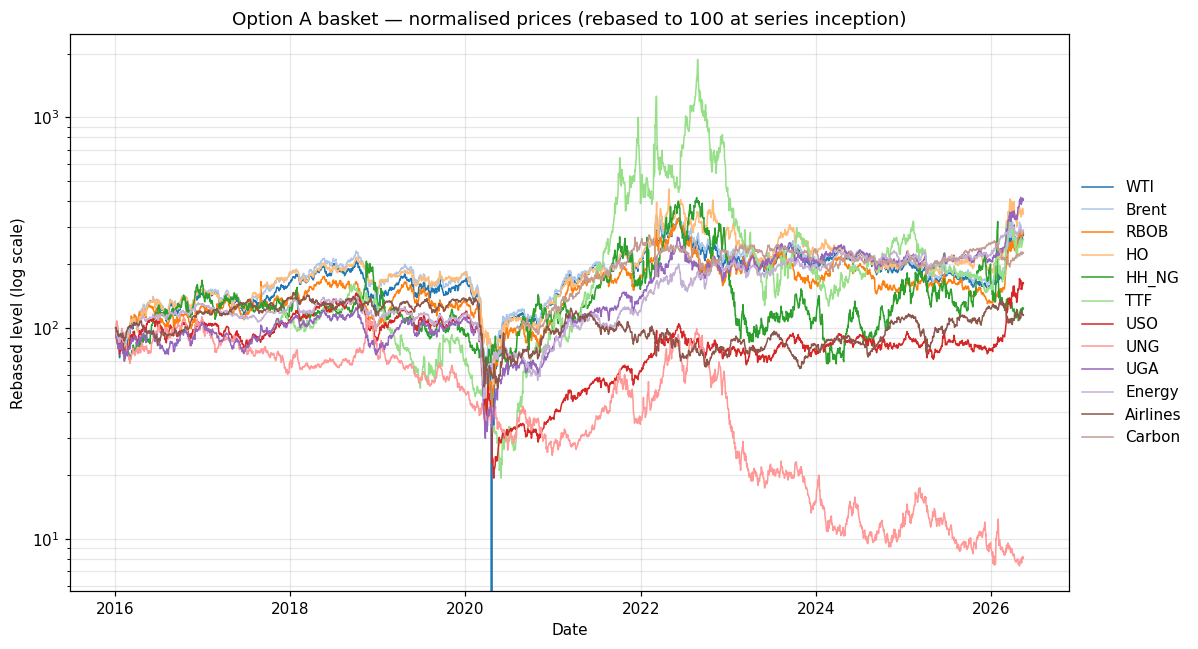

In [7]:
fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.get_cmap("tab20")
for i, name in enumerate(COMMODITY_KEYS):
    s = prices_wide[name].dropna()
    if s.empty:
        continue
    rebased = 100 * s / s.iloc[0]
    ax.plot(rebased.index, rebased.values, label=name, lw=1.0, color=cmap(i % 20))
ax.set_yscale("log")
ax.set_xlabel("Date")
ax.set_ylabel("Rebased level (log scale)")
ax.set_title("Option A basket — normalised prices (rebased to 100 at series inception)")
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=False)
ax.grid(alpha=0.3, which="both")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_normalised_prices.png")
plt.show()


c:\Users\Bryant\AppData\Local\Programs\Python\Python311\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


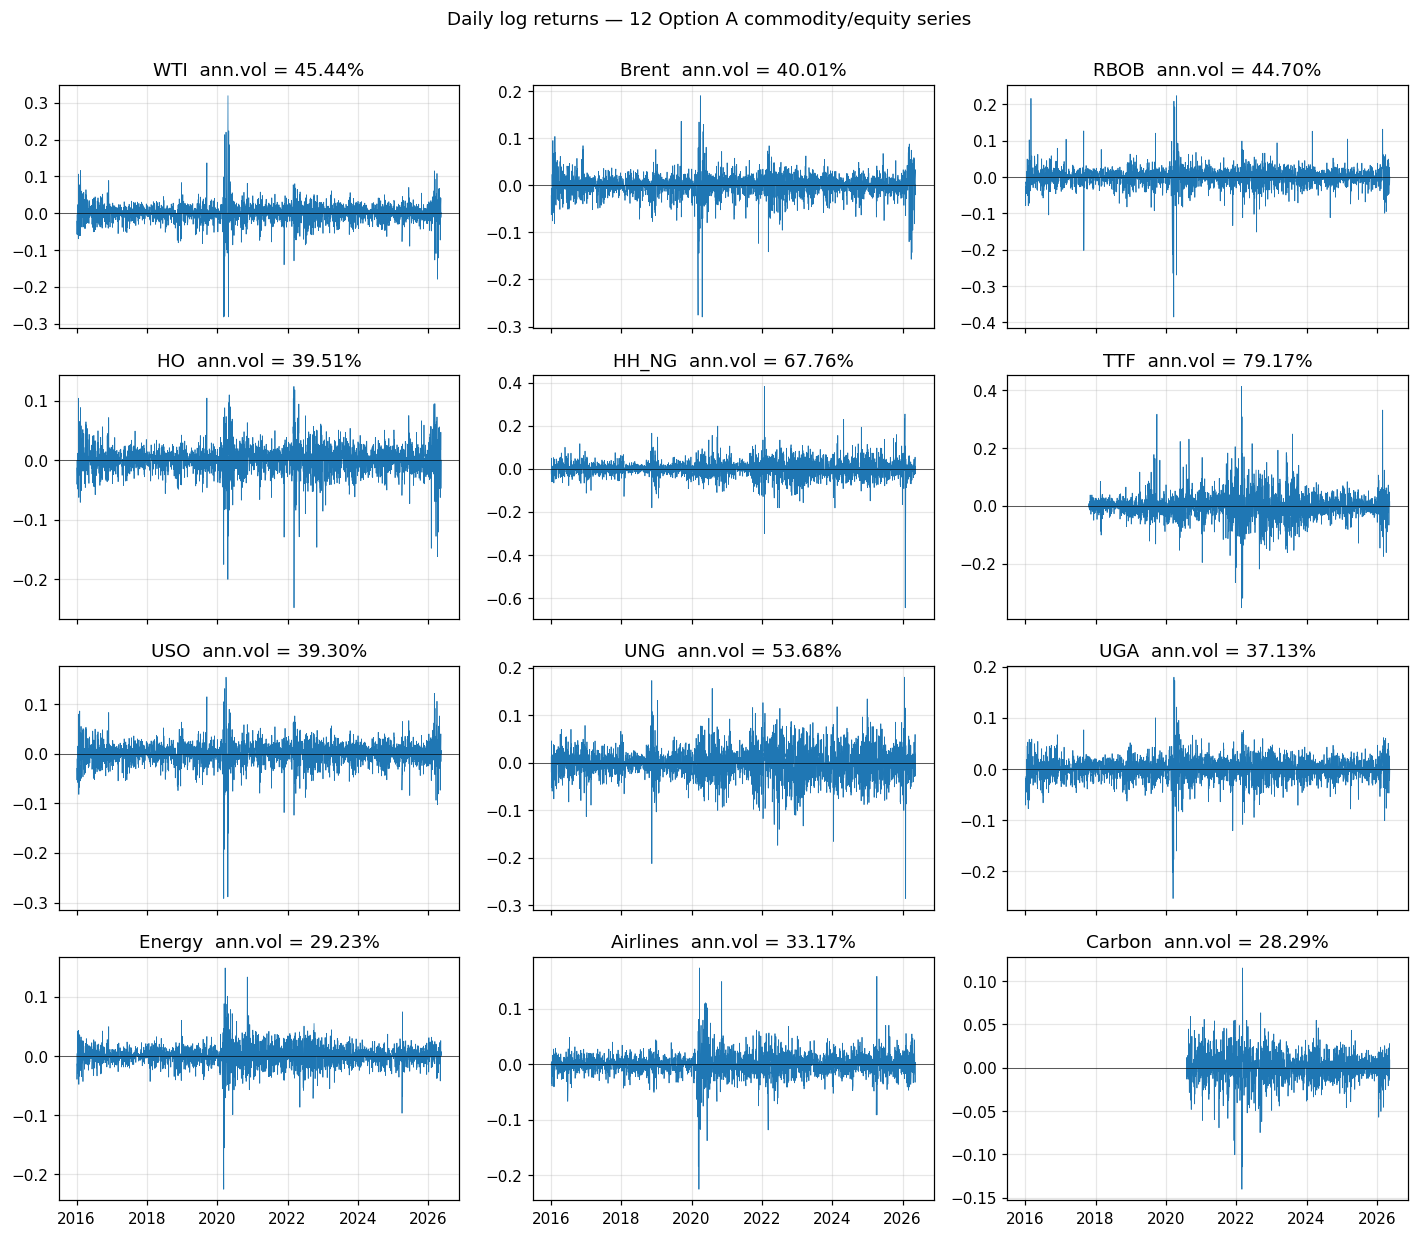

In [8]:
n = len(COMMODITY_KEYS)
ncols = 3
nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 2.8 * nrows), sharex=True)
axes_flat = axes.flatten() if n > 1 else [axes]
for ax, name in zip(axes_flat, COMMODITY_KEYS):
    s = prices_wide[name].dropna()
    if s.empty:
        ax.set_title(f"{name} — no data")
        ax.set_visible(False)
        continue
    rets = np.log(s).diff().dropna()
    ann_vol = float(rets.std() * np.sqrt(252))
    ax.plot(rets.index, rets.values, lw=0.5)
    ax.axhline(0, color="black", lw=0.4)
    ax.set_title(f"{name}  ann.vol = {ann_vol:.2%}")
    ax.grid(alpha=0.3)
for extra_ax in axes_flat[n:]:
    extra_ax.set_visible(False)
fig.suptitle(f"Daily log returns — {n} Option A commodity/equity series", y=1.00)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "02_log_returns_small_multiples.png")
plt.show()

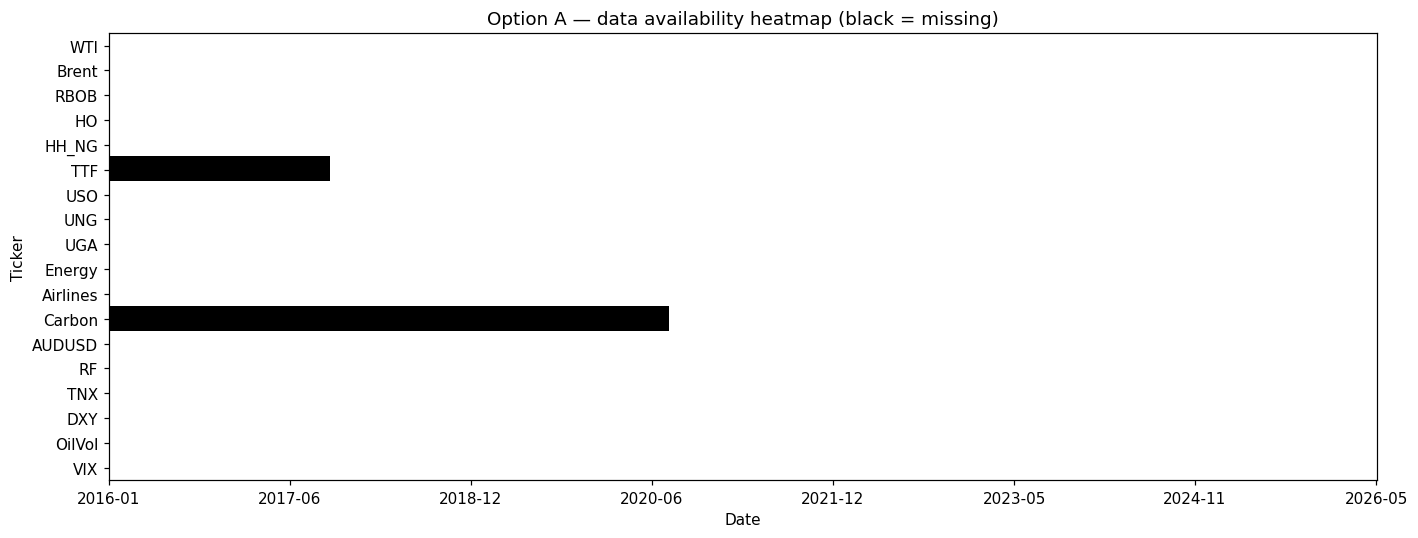

In [10]:
# Combine price-like and exogenous series so the heatmap covers everything
combined = pd.concat([prices_wide, exog_wide], axis=1)
names = [c for c in combined.columns if c in TICKERS]  # only base tickers, skip computed (e.g. BrentWTI_spread)

matrix = np.zeros((len(names), len(bday_index)), dtype=float)
for i, name in enumerate(names):
    s = combined[name]
    matrix[i, :] = (~s.isna()).astype(float).values

fig, ax = plt.subplots(figsize=(13, 5))
ax.imshow(matrix, aspect="auto", interpolation="nearest", cmap="gray",
          extent=[0, len(bday_index), len(names), 0], vmin=0, vmax=1)
tick_positions = np.linspace(0, len(bday_index) - 1, 8).astype(int)
tick_labels = [bday_index[t].strftime("%Y-%m") for t in tick_positions]
ax.set_xticks(tick_positions)
ax.set_xticklabels(tick_labels)
ax.set_yticks(np.arange(len(names)) + 0.5)
ax.set_yticklabels(names)
ax.set_xlabel("Date")
ax.set_ylabel("Ticker")
ax.set_title("Option A — data availability heatmap (black = missing)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "03_missing_heatmap.png")
plt.show()

## Step 5: Run tracking-gap diagnostic

In [13]:
gap_path = QUALITY_DIR / "tracking_gap_report.csv"
gap_fresh = (
    gap_path.exists()
    and datetime.fromtimestamp(gap_path.stat().st_mtime)
        > datetime.now() - timedelta(hours=24)
)
if gap_fresh:
    print("[CACHE] tracking_gap_report.csv is fresh (<24h); skipping subprocess")
else:
    result = subprocess.run(
        [sys.executable, str(PROJECT_ROOT / "scripts" / "data_quality.py")],
        capture_output=True, text=True, cwd=str(PROJECT_ROOT),
    )
    print(result.stdout)
    if result.returncode != 0:
        print("STDERR:", result.stderr)

if gap_path.exists():
    gap_report = pd.read_csv(gap_path)
    print(gap_report.to_string(index=False))
else:
    print("[WARN] tracking_gap_report.csv not produced")

[GAP] USO (USO) vs reference CL=F
  [OK] n=2603, corr=0.880, TE_ann=0.2208
[GAP] UNG (UNG) vs reference NG=F
  [OK] n=2606, corr=0.818, TE_ann=0.3977
[GAP] UGA (UGA) vs reference RB=F
  [OK] n=2606, corr=0.876, TE_ann=0.2210
[WROTE] C:\Users\Bryant\Documents\USYD\Year 3\sem 2\QBUS3850\group assignment\repo_v2\Time-Series-Forecasting\data\quality\tracking_gap_report.csv (3 rows)

proxy proxy_symbol reference_symbol  n_obs  correlation  r_squared     beta  tracking_error_ann  mean_ann_diff  proxy_ann_return  proxy_ann_vol  ref_ann_return  ref_ann_vol
  USO          USO             CL=F   2603     0.879854   0.774142 0.738198            0.220831      -0.070166          0.086094       0.388425        0.156260     0.462961
  UNG          UNG             NG=F   2606     0.817677   0.668596 0.647703            0.397735      -0.264234         -0.243438       0.546742        0.020796     0.690220
  UGA          UGA             RB=F   2606     0.875560   0.766605 0.727046            0.220956    

## Step 6: Acceptance check

In [17]:
checks = []

# Raw CSVs — one per ticker
raw_csv_count = sum(1 for n in TICKERS if (RAW_DIR / f"{n}.csv").exists())
checks.append((
    f"All {len(TICKERS)} raw CSVs present",
    raw_csv_count == len(TICKERS),
    f"{raw_csv_count}/{len(TICKERS)}",
))

# prices.parquet — PRICE_KEYS + BrentWTI_spread + USGCJet + 2 cracks (JetBrent, HOBrent)
pq = PROCESSED_DIR / "prices.parquet"
pq_ok = pq.exists()
pq_cols = pd.read_parquet(pq).shape[1] if pq_ok else 0
expected_price_cols = len(PRICE_KEYS) + 4  # +BrentWTI_spread +USGCJet +JetBrent_crack +HOBrent_crack
checks.append((
    f"prices.parquet exists with {expected_price_cols} columns",
    pq_ok and pq_cols == expected_price_cols,
    f"cols={pq_cols}",
))

# returns.parquet
rt = PROCESSED_DIR / "returns.parquet"
checks.append(("returns.parquet exists", rt.exists(), ""))

# exogenous_features.parquet — EXOGENOUS_KEYS + 3 EIA weekly series
ex = PROCESSED_DIR / "exogenous_features.parquet"
ex_ok = ex.exists()
ex_cols = pd.read_parquet(ex).shape[1] if ex_ok else 0
expected_exog_cols = len(EXOGENOUS_KEYS) + 3  # +CrudeStocks +DistStocks +RefineryUtil
checks.append((
    f"exogenous_features.parquet exists with {expected_exog_cols} columns",
    ex_ok and ex_cols == expected_exog_cols,
    f"cols={ex_cols}",
))

# CSV mirror
checks.append(("prices.csv exists", (PROCESSED_DIR / "prices.csv").exists(), ""))

# Figures
fig_names = [
    "01_normalised_prices.png",
    "02_log_returns_small_multiples.png",
    "03_missing_heatmap.png",
]
fig_ok = all((FIGURES_DIR / fn).exists() for fn in fig_names)
checks.append(("All 3 figures exist", fig_ok, ""))

# Tracking-gap report
gap_path = QUALITY_DIR / "tracking_gap_report.csv"
gap_rows = len(pd.read_csv(gap_path)) if gap_path.exists() else 0
checks.append(("tracking_gap_report.csv has >=1 row", gap_rows >= 1, f"rows={gap_rows}"))

# Summary
sm = PROCESSED_DIR / "summary.csv"
checks.append(("summary.csv exists", sm.exists(), ""))

# v2 musts
checks.append(("END date is 2026-05-15", END == "2026-05-15", f"END={END}"))
checks.append(("AUDUSD in basket", "AUDUSD" in TICKERS, ""))
checks.append(("TNX in basket", "TNX" in TICKERS, ""))

for label, passed, extra in checks:
    tag = "[OK]  " if passed else "[FAIL]"
    print(f"{tag} {label}" + (f"  ({extra})" if extra else ""))

print()
print("DATA ACQUISITION (OPTION A) COMPLETE")
print("All Yahoo + EIA series loaded; outputs ready for downstream notebooks.")

[OK]   All 18 raw CSVs present  (18/18)
[OK]   prices.parquet exists with 17 columns  (cols=17)
[OK]   returns.parquet exists
[OK]   exogenous_features.parquet exists with 8 columns  (cols=8)
[OK]   prices.csv exists
[OK]   All 3 figures exist
[OK]   tracking_gap_report.csv has >=1 row  (rows=3)
[OK]   summary.csv exists
[OK]   END date is 2026-05-15  (END=2026-05-15)
[OK]   AUDUSD in basket
[OK]   TNX in basket

DATA ACQUISITION (OPTION A) COMPLETE
All Yahoo + EIA series loaded; outputs ready for downstream notebooks.
